# Historical Commission Review

Per Waltham's zoning code [section 23-2](https://ecode360.com/26936024), structures older than 75 years must go through Historical Commission Review. The Historical Commission is tasked
to determine whether or not a structure should be preserved or if demoltion need not be denied to preserve historic character. Our zoning code has _long_ forbidden multi-family housing,
meaning a lot of our housing stock is low density. Historical review could present a barrier to necessary development of housing. The more restrictive our zoning code is, the more structures
could be subject to review. Given the subjective criteria allowed by the code, there's a possibility that we'd be stuck with insufficient housing that becomes increasingly expensive to maintain.

In [8]:
import pandas as pd
import geopandas as gpd
import datetime

from data.connect_db import get_db
from waltham.constants import MASSGIS_CRS

from tqdm import tqdm

conn = get_db()

In [2]:
parcels_query = """
select
    "geom", "LOC_ID"
from 
    \"M308TaxPar_CY25_FY25\"
"""

parcels_df = gpd.read_postgis(parcels_query, conn, geom_col="geom")

In [3]:
assess_query = """
select
    "LOC_ID", "PROP_ID", "UNITS", "YEAR_BUILT", "USE_CODE"::integer, "STYLE"
from
    \"M308Assess_CY25_FY25\"
"""

assess_df = pd.read_sql(assess_query, conn)

In [4]:
properties_df = parcels_df.merge(assess_df, how="outer", on="LOC_ID")

In [9]:
# model how much ages into historical status over time, over a generation
this_year = datetime.date.today().year

properties_df["IMPUTED"] = properties_df["YEAR_BUILT"].map(lambda x: x in [float("nan"), 0])
residential_criteria = (properties_df["USE_CODE"] < 200) & (properties_df["USE_CODE"].map(lambda x: x not in range(130, 141)))

trend_data = []

for COMPARE_YEAR in tqdm(range(this_year, this_year + 20)):
    # assume age is 75, if unknown
    properties_df["YEAR_BUILT"] = properties_df["YEAR_BUILT"].replace(0, COMPARE_YEAR - 75)
    properties_df["YEAR_BUILT"] = properties_df["YEAR_BUILT"].fillna(COMPARE_YEAR - 75)

    properties_df["HISTORIC"] = (COMPARE_YEAR - properties_df["YEAR_BUILT"]) >= 75

    # historic housing
    properties_df["HISTORIC_RESIDENTIAL"] = properties_df.apply(lambda row: 
        row["HISTORIC"] and (row["USE_CODE"] < 200) and (row["USE_CODE"] not in range(130, 141)),
        axis=1
    )

    other_residential = properties_df[residential_criteria & ~properties_df["HISTORIC_RESIDENTIAL"]]
    historic_resdential = properties_df[residential_criteria & properties_df["HISTORIC_RESIDENTIAL"]]

    trend_data.append({
        "year": COMPARE_YEAR,
        "historic_residential": len(historic_resdential),
        "other_residential": len(other_residential),
        "historic_residential_units": historic_resdential["UNITS"].sum(),
        "other_residential_units": other_residential["UNITS"].sum()
    })
    
trend_data_df = pd.DataFrame(trend_data)

100%|██████████| 20/20 [00:01<00:00, 15.81it/s]


<Axes: title={'center': 'Residential structures changing historic status'}, xlabel='year'>

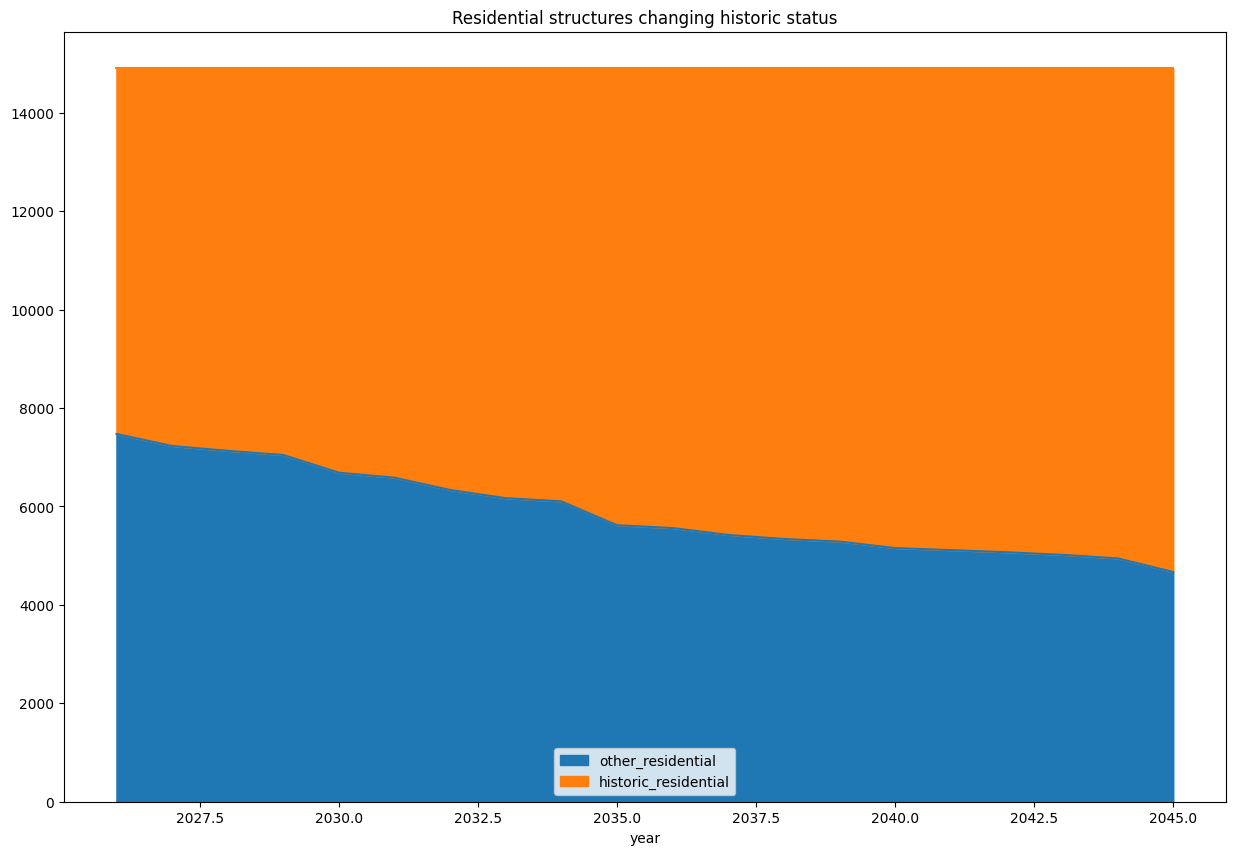

In [6]:
trend_data_df.plot.area(
    x="year", y=["other_residential", "historic_residential"], 
    title="Residential structures changing historic status",
    figsize=(15, 10)
)

<Axes: title={'center': 'Residential units changing historic status'}, xlabel='year'>

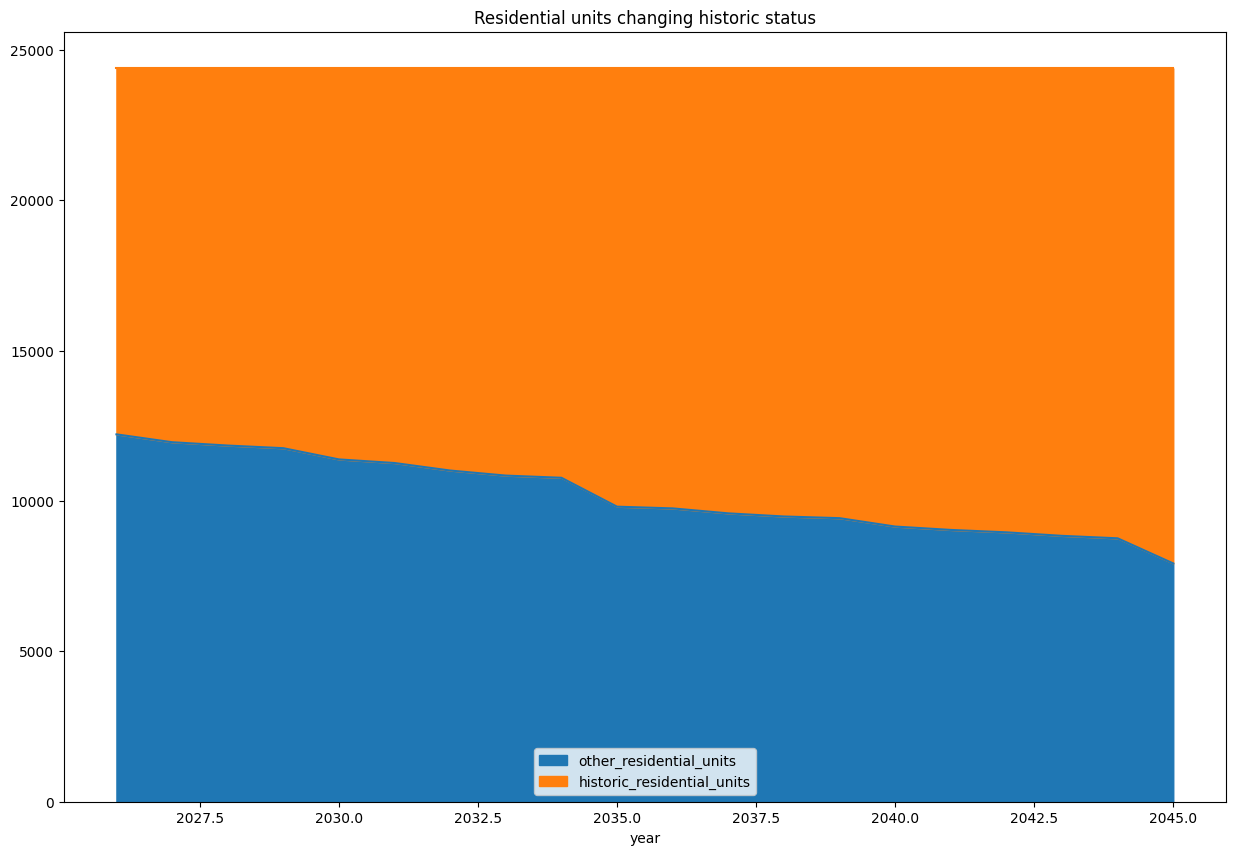

In [7]:
trend_data_df.plot.area(
    x="year",
    y=["other_residential_units", "historic_residential_units"],
    title="Residential units changing historic status",
    figsize=(15, 10)
)